In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [17]:
df=pd.read_csv("data.csv")
df.head()


,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


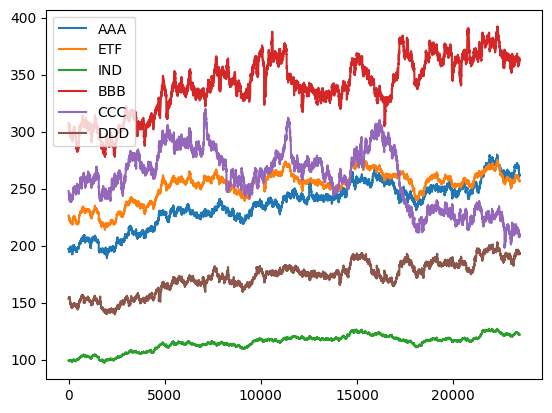

In [18]:
stock_codes=["AAA","ETF","IND","BBB","CCC","DDD"]
#fig, ax = plt.subplots(figsize=(15, 5))
#balance= pd.Series(train_data['resp']).cumsum()
#ax.set_xlabel ("Trade", fontsize=18)
#ax.set_ylabel ("Cumulative resp", fontsize=18);
for name in stock_codes:
    plt.plot(df.index,df[name],label=name)

plt.legend()


In [19]:
#Johansen test critical values
critical_values = {0: {.9: 13.4294, .95: 15.4943, .99: 19.9349},
                   1: {.9: 2.7055, .95: 3.8415, .99: 6.6349}}

trace0_cv = critical_values[0][.95] # critical value for 0 cointegration relationships
trace1_cv = critical_values[1][.95] # critical value for 1 cointegration relationship

In [ ]:
for i in range(len(stock_codes)):
    pricediff = None
    for j in range(i+1, len(stock_codes)):
        stock_code1 = stock_codes[i]
        stock_code2 = stock_codes[j]
        
        data1 = df[stock_code1]
        data2 = df[stock_code2]

        result=pd.DataFrame()
        result[stock_code1]=data1
        result[stock_code2]=data2
        #print(result.head())
        
        cj = coint_johansen(result[[stock_code1, stock_code2]], det_order=1, k_ar_diff=1)
        
        if cj.trace_stat[0] > cj.trace_stat_crit_vals[0][1]:
            print(f"Cointegration found for {stock_code1} and {stock_code2}")
            pricediff = result[[stock_code1, stock_code2]] @ cj.evec[0]

    #why does everyone has pairtrading potential

Cointegration found for AAA and ETF
Cointegration found for AAA and IND
Cointegration found for AAA and BBB
Cointegration found for AAA and CCC
Cointegration found for AAA and DDD
Cointegration found for ETF and IND
Cointegration found for ETF and BBB
Cointegration found for ETF and CCC
Cointegration found for ETF and DDD
Cointegration found for IND and BBB
Cointegration found for IND and CCC
Cointegration found for IND and DDD
Cointegration found for BBB and CCC
Cointegration found for BBB and DDD
Cointegration found for CCC and DDD
